<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%206/full_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 — CNNs From Scratch: Convolution, Pooling, and a Real Network

**Goal:** Build the two core operations of computer vision by hand — **convolution** and **pooling** — then assemble a real **convolutional neural network** in PyTorch.

Earlier networks flattened images into flat vectors, discarding spatial structure. CNNs keep the 2D layout and process it with two moves, repeated:

| Operation | What it does |
|---|---|
| **Convolution** | slide a small kernel, dot-product each patch → detect local patterns (edges, textures) |
| **Pooling** | take the max of each small region → shrink spatially, keep the strongest signals |

Stacked together — `[Conv → ReLU → Pool]` repeated, then a Dense layer — they form the architecture behind modern image recognition.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

%matplotlib inline

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train = torchvision.datasets.MNIST(root='./data', train=True,  transform=transform, download=True)
test  = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


---
## 1. The Convolution Operation

Slide a kernel over every valid position; at each one, grab the patch beneath it, multiply element-wise with the kernel, and sum. That single sum is one output pixel.

**Output size (stride 1, no padding):** for an $N{\times}N$ image and $K{\times}K$ kernel, the output is $(N-K+1)\times(N-K+1)$.

The key line, `out[i,j] = np.sum(patch * kernel)`, is the dot product at that position — element-wise multiply, then sum.

In [3]:
def convolution(image, kernel):
  img_h, img_w = image.shape
  ker_h, ker_w = kernel.shape

  out_h = img_h - ker_h + 1      # (N - K + 1)
  out_w = img_w - ker_w + 1

  out = np.zeros((out_h, out_w))

  for i in range(out_h):
    for j in range(out_w):
      patch = image[i:i+ker_h, j:j+ker_w]   # window under the kernel
      out[i, j] = np.sum(patch * kernel)    # dot product -> one value

  return out

In [4]:
# Sanity check: all-ones kernel just sums each 3x3 patch. Top-left = 1+..+9 = 45.
image = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 0],
    [7, 8, 9, 2, 3],
    [1, 0, 1, 4, 5],
    [2, 3, 4, 0, 1],
], dtype=float)

print(convolution(image, np.ones((3, 3))))

[[45. 36. 25.]
 [41. 36. 31.]
 [35. 31. 29.]]


---
## 2. Edge Detection — Seeing a Kernel Work

A hand-designed kernel detects edges. The vertical-edge kernel
$$\begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}$$
subtracts the left column from the right column of each patch. Flat areas (left ≈ right) → ~0; a sharp left-to-right change (a **vertical edge**) → large value. A trained CNN learns kernels like this automatically.

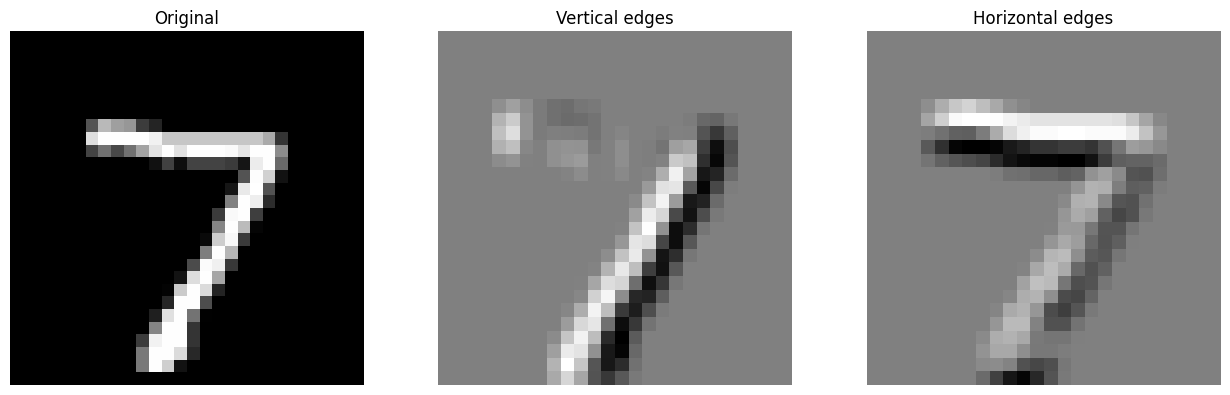

In [5]:
image = test.data[0].numpy().astype(float)

vertical_kernel = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])
horizontal_kernel = np.array([[-1, -1, -1],
                              [ 0,  0,  0],
                              [ 1,  1,  1]])

vertical_edges   = convolution(image, vertical_kernel)
horizontal_edges = convolution(image, horizontal_kernel)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image, cmap='gray');            axes[0].set_title('Original');    axes[0].axis('off')
axes[1].imshow(vertical_edges, cmap='gray');   axes[1].set_title('Vertical edges');   axes[1].axis('off')
axes[2].imshow(horizontal_edges, cmap='gray'); axes[2].set_title('Horizontal edges'); axes[2].axis('off')
plt.tight_layout(); plt.show()

---
## 3. Max Pooling

Pooling **downsamples** a feature map: slide a small window (usually 2×2, stride 2, non-overlapping) and keep only the **maximum** value in each region.

**Why the max?** A convolution output means "how strongly is this feature present here." Taking the max keeps the strongest "yes, it's here" signal and discards the exact position. This gives two benefits:
- **Downsampling** — less data, less compute for later layers
- **Translation invariance** — a small shift in the input barely changes the maxes

Note there are no learnable weights in pooling — it just needs the window *size*, not a kernel of numbers.

In [6]:
def max_pool(image, kernel_size, stride=None, padding=0):
  if stride is None:
    stride = kernel_size          # default: non-overlapping windows

  if padding > 0:
    image = np.pad(image, padding, mode='constant', constant_values=0)

  img_h, img_w = image.shape
  out_h = (img_h - kernel_size) // stride + 1
  out_w = (img_w - kernel_size) // stride + 1

  out = np.zeros((out_h, out_w))

  for i in range(out_h):
    for j in range(out_w):
      row = i * stride
      col = j * stride
      patch = image[row:row+kernel_size, col:col+kernel_size]
      out[i, j] = np.max(patch)     # the MAX of the window

  return out

In [7]:
# Test: 2x2 pooling on a 4x4. The four corners -> [[6,4],[7,9]]
x = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 8, 0],
    [1, 4, 3, 9],
], dtype=float)

print("From scratch:")
print(max_pool(x, kernel_size=2))

From scratch:
[[6. 4.]
 [7. 9.]]


### Confirm against PyTorch

PyTorch's `nn.MaxPool2d` should give the identical result. Note PyTorch expects **4D input**: `(batch, channels, height, width)` — the standard shape for all image data in PyTorch.

In [8]:
x_t = torch.from_numpy(x).float().reshape(1, 1, 4, 4)   # (batch, channel, H, W)
pool = nn.MaxPool2d(2)

print("PyTorch MaxPool2d:")
print(pool(x_t))     # matches [[6,4],[7,9]]

PyTorch MaxPool2d:
tensor([[[[6., 4.],
          [7., 9.]]]])


---
## 4. The PyTorch Building Blocks

`nn.Conv2d(in_channels, out_channels, kernel_size)` is the learnable version of our convolution — it holds `out_channels` kernels and learns them during training. `in_channels` is the input depth: **1 for grayscale**, 3 for RGB, or however many channels the previous layer output.

The key mental model: **channels are depth.** A conv layer with `out_channels=16` produces 16 feature maps, one per learned kernel.

In [9]:
conv = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=2, stride=2)
print("Conv output shape:", conv(x_t).shape)   # (1, 2, 2, 2): 2 channels out, 2x2 spatial

Conv output shape: torch.Size([1, 2, 2, 2])


---
## 5. A Real CNN

Now stack it into the classic pattern: **`[Conv → ReLU → Pool]` twice**, then flatten and a Linear layer to 10 class scores.

### Tracing the shapes (this is the part that trips everyone up)
Starting from a `(1, 28, 28)` MNIST image:

| Layer | Operation | Output shape |
|---|---|---|
| Input | — | (1, 28, 28) |
| Conv2d(1, 16, 3) | 28 − 3 + 1 = 26 | (16, 26, 26) |
| MaxPool2d(2) | 26 / 2 = 13 | (16, 13, 13) |
| Conv2d(16, 32, 3) | 13 − 3 + 1 = 11 | (32, 11, 11) |
| MaxPool2d(2) | 11 / 2 = 5 (floor) | (32, 5, 5) |
| Flatten | 32 × 5 × 5 | 800 |
| Linear(800, 10) | — | 10 |

So the first Linear layer needs `in_features = 32*5*5 = 800`. Notice the pattern: spatial size **shrinks** (28 → 5) while channel depth **grows** (1 → 32) — the network trading "where things are" for "what things are."

**Pro tip:** rather than hand-computing 800, many people just run a batch through the conv layers and `print(x.shape)` before the Linear, then read off the number.

In [10]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Conv2d(1, 16, 3),    # (1,28,28)  -> (16,26,26)
        nn.ReLU(),
        nn.MaxPool2d(2),        # (16,26,26) -> (16,13,13)
        nn.Conv2d(16, 32, 3),   # (16,13,13) -> (32,11,11)
        nn.ReLU(),
        nn.MaxPool2d(2),        # (32,11,11) -> (32,5,5)
        nn.Flatten(),           # -> 32*5*5 = 800
        nn.Linear(32 * 5 * 5, 10)
    )

  def forward(self, x):
    return self.layers(x)

In [11]:
# Sanity check the forward pass with a fake batch
cnn = CNN()
sample = torch.randn(64, 1, 28, 28)      # (batch, channel, H, W)
print("Output shape:", cnn(sample).shape)  # expect (64, 10)

Output shape: torch.Size([64, 10])


`(64, 10)` — one row per image in the batch, 10 class scores each. The forward pass works.

---
## 6. Ready to Train

The training setup is identical to the MLP — the only difference is we feed the CNN the **unflattened** `(batch, 1, 28, 28)` images so it can convolve over the 2D structure (no `.view(-1, 784)` here). Training itself is the next session.

In [12]:
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader  = DataLoader(test,  batch_size=64, shuffle=False)

cnn = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn.parameters(), lr=0.15)

print("Ready to train:", cnn)

Ready to train: CNN(
  (layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=800, out_features=10, bias=True)
  )
)


---
## Summary

| Concept | Key point |
|---|---|
| **Convolution** | slide kernel, dot-product each patch → feature map |
| **Edge kernels** | simple 3×3 grids detect oriented edges; CNNs learn these |
| **Max pooling** | keep the max of each region → downsample + translation invariance |
| **Conv2d / MaxPool2d** | PyTorch layers; input is 4D (batch, channels, H, W) |
| **CNN pattern** | [Conv→ReLU→Pool] repeated → Flatten → Linear |
| **Shape rule** | spatial size shrinks, channel depth grows with depth |
| **Flatten size** | trace shapes (or print) to size the first Linear layer |

**The big idea:** convolutions extract local patterns and pooling condenses them; stacked, they build a hierarchy from edges to objects. This CNN's forward pass runs and outputs `(batch, 10)`.

**Next: train this network, then move to CIFAR-10 — real color images.**